# Transformer Architecture Beside Attention Mechanism

## Why?

The groundbreaking research paper **["Attention Is All You Need"](https://arxiv.org/pdf/1706.03762)**, published by Google researchers in 2017, introduced the **Transformer architecture**, which forms the foundation of modern LLMs.

At the heart of the Transformer architecture lies the **multi-head attention mechanism**, which we have already reconstructed from first principles in a previous [computational essay](https://github.com/umairkhancis/llm-under-the-hood/blob/main/attention_mechanism_module/notebooks/multihead-attention-essay.ipynb).

However, the Transformer architecture consists of more than just the multi-head attention mechanism. Several additional components work together to form a complete Transformer block.

<img src="images/original-transformer-architecture.png" width="20%" />

## Goal

In this computational essay, we will construct a complete **Transformer block** by integrating the multi-head attention mechanism that we have already implemented with the remaining building blocks of the Transformer architecture.

This Transformer block will eventually serve as the fundamental building block of the GPT architecture, also known as the **decoder-only Transformer**.

<img src="images/transformer-block.png" width="30%" />


## Recipe
1. Codify the `DummyTransformerBlock` to understand the overall structure and inputs and output dimensions.
2. Prepare `LayerNorm` component.
3. Prepare `Feedforward` component
4. Add `Shortcut` connection.
5. Add `Dropout` component.
6. Codify the real `TransformerBlock` abstraction.

## Step 1: Codify `DummyTransformerBlock`

- Input Shape: `[2, 4, 768]`
- Output Shape: `[2, 4, 768]`

_i.e. Batch of `2 training examples` each having `4 tokens` and each token is represented in `768 dimensional embedding vector`._

In [1]:
import torch
import torch.nn as nn

# Import already prepared `MultiHeadAttention` abstraction
import sys 
sys.path.append("../..")
from attention_mechanism_module import MultiHeadAttention 

class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_window_length=cfg["context_window_size"],
            num_heads=cfg["n_heads"], 
            dropout_rate=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        
        # TODO: Replace `DummyFeedForward` with real `LayerNorm`.
        self.ff = DummyFeedForward(cfg)

        # TODO: Replace `DummyLayerNorm` with real `LayerNorm`.
        self.norm1 = DummyLayerNorm(cfg["emb_dim"])
        self.norm2 = DummyLayerNorm(cfg["emb_dim"])
        
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # TODO: Implement connections
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

    def forward(self, x):
        # TODO: Implement normalization layer
        return x

class DummyFeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        # TODO: Implement feed forward neural network layers
        return x

Example of using a transformer block like `DummyTransformerBlock` which will eventually be replaced with real transformer block by the end of this essay.

In [2]:
torch.manual_seed(123)

CONFIG = {
    "vocab_size": 50257,          # Vocabulary size
    "context_window_size": 1024,  # Context window size
    "emb_dim": 768,               # Embedding dimension
    "n_heads": 12,                # Number of attention heads
    "n_layers": 12,               # Number of layers
    "drop_rate": 0.1,             # Dropout rate
    "qkv_bias": False             # Query-Key-Value bias
}

x = torch.rand(2, 4, 768)
block = DummyTransformerBlock(cfg=CONFIG)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


## Step 2: Prepare `LayerNorm` Component

Understand normalization using random mock inputs and then apply it to actual training examples.

<img src="images/normalization-layer.png" width="40%"/>

Let's say, we have a neural network layer which takes in 5 values and outputs 6 values.

These values are not normalized i.e they are not centered around mean which implies mean=0 and variance=1.

In [3]:
torch.manual_seed(123)
torch.set_printoptions(sci_mode=False)

# Consider 1 batch having 2 examples, each having 5 values.
batch = torch.randn(2, 5)

# Mock neural network with ReLU activation function to map 5 values into 6 output values.
nn_layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())

# Invoke `nn_layer`
output = nn_layer(batch)
print(f"Output: {output}\n")

# Calculate Mean & Variance on existing `output`
mean = output.mean(dim=-1, keepdim=True)
variance = output.var(dim=-1, keepdim=True)

print(f"Original mean of neural network layer output: {mean}\n")
print(f"Original variance of neural network output: {variance}\n")

Output: tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

Original mean of neural network layer output: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)

Original variance of neural network output: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)



**Note:** _mean != 0 and variance != 1_

### Now normalize the output values centered around the mean.

In [4]:
# Calculate Mean & Variance on normalized version of `hidden_out`
normed = (output - mean) / torch.sqrt(variance)
normalized_mean = normed.mean()
normalized_variance = normed.var()

print(f"Normalized variance of neural network output: {normalized_variance:.3f}")
print(f"Normalized mean of neural network layer output: {normalized_mean:.3f}")

Normalized variance of neural network output: 0.909
Normalized mean of neural network layer output: -0.000


**Note:** _mean = 0 and variance = 1_

### Real Abstraction of `LayerNorm`

**Allowing the Network to "Undo" Normalization**

Standard normalization forces activations to have a mean of **0** and a variance of **1**. While this stabilizes training, it also imposes a strong assumption on the data: that every layer performs best with perfectly normalized activations.

In practice, this is not always true. Some layers may perform better with activations that are shifted or scaled differently.

This is why normalization layers introduce two learnable parameters, **`scale`** and **`shift`**. During training, backpropagation learns their optimal values. If strict normalization is not beneficial for a particular layer, the network can automatically adjust **`scale`** and **`shift`** to undo part—or even all—of the normalization, restoring the scale and distribution that best supports learning.

In [5]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        
        return self.scale * norm_x + self.shift

**Note:**
- `eps` is to avoid divide by zero error.
- `scale` is learn appropriate weights to make the normalization operation (division by variance) fruitful either by undoing it altogether or adjusting it appropriately.
- `shift` is learn appropriate weights to make the normalization operation (subtraction by mean) fruitful either by undoing it altogether or adjusting it appropriately.
- `unbiased=False` means sample statistics rather than population statistics.

### Usage of `LayerNorm` Abstraction

In [6]:
torch.manual_seed(123)
torch.set_printoptions(sci_mode=False)

# Consider 1 batch having 2 examples, each having 5 values.
batch = torch.randn(2, 5)

# Mock neural network with ReLU activation function to map 5 values into 6 output values.
nn_layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())

# Invoke `nn_layer`
output = nn_layer(batch)
print(f"Output: {output}\n")

# Invoke `LayerNorm` on top of `nn_layer` values
layer_norm = LayerNorm(6)
output_normalized = layer_norm(output)

print(f"LayerNorm Output: {output_normalized}\n")
print(f"LayerNorm Output Mean: {output_normalized.mean(dim=-1, keepdim=True)}\n")
print(f"LayerNorm Output Variance: {output_normalized.var(dim=-1, keepdim=True, unbiased=False)}\n")

Output: tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)

LayerNorm Output: tensor([[ 0.6745,  1.5470, -0.9549,  0.6431, -0.9549, -0.9549],
        [-0.0207,  0.1228, -1.1913,  1.6619,  0.6186, -1.1913]],
       grad_fn=<AddBackward0>)

LayerNorm Output Mean: tensor([[-0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)

LayerNorm Output Variance: tensor([[0.9995],
        [0.9997]], grad_fn=<VarBackward0>)



## Step 3: Prepare `Feedforward` Component

A typical feed forward neural network component consist of following layers in a sequential fashion:
- a linear layer scaling number of input values, then
- a non-linear activation function (like ReLU or GELU), then
- a linear layer to scale to the number of output values required.

<img src="images/feedforward-block.png" width="30%" />

### GELU Activation Function Implementation

<img src="images/gelu-activation.png" width="40%" />

In [7]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))

### Comparing ReLU vs GELU

GELU is found generally better in learning optimization properties.

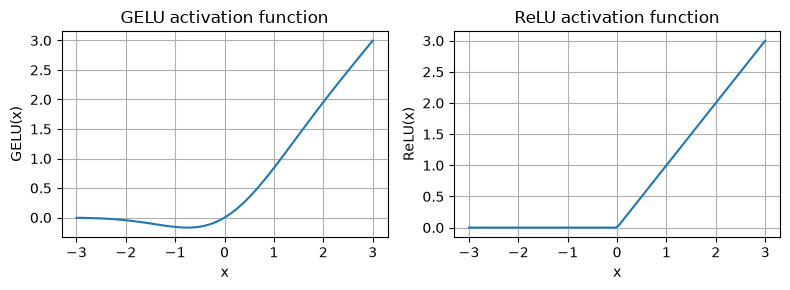

In [8]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Feedforward Abstraction
Feedforward module internally scale number of input values then scale again to the number of output values required.

<img src="images/feedforward-network-overview.png" width="30%"/>    <img src="images/feedforward-insights.png" width="40%"/>

In [9]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

### Usage of Feedforward Abstraction


In [10]:
# Consider 2 examples, each having 5 tokens and each token is represented as 768 embedding dimensions.
x = torch.rand(2, 3, 768)

ff = FeedForward(cfg=CONFIG)
out = ff(x)

print(f"Feedforward Network Output Shape: {out.shape}\n")

print(f"FeedForward Network Layers: {ff.layers}")

Feedforward Network Output Shape: torch.Size([2, 3, 768])

FeedForward Network Layers: Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GELU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
)


## Step 4: Add Shortcut Connection

**Why?**

Let’s discuss the concept behind shortcut connections, also known as skip or residual connections. Originally, shortcut connections were proposed for deep networks in computer vision (specifically, in residual networks) to mitigate the challenge of vanishing gradients. 

The vanishing gradient problem refers to the issue where gradients (which guide weight updates during training) become progressively smaller as they propagate backward through the layers, making it difficult to effectively train earlier layers.

To illustrate vanishing gradient problem, let's consider a `ExampleDeepNeuralNetwork` without shortcut connection and then demonstrate the impact of adding shortcut connection in the network.

In [11]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target)

    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

### Usage of `ExampleDeepNeuralNetwork` without Shortcut Connection

In [12]:
torch.manual_seed(123)
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1.0, 0.0, -1.0]])

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011158833047375
layers.2.0.weight has gradient mean of 0.0007152041071094573
layers.3.0.weight has gradient mean of 0.0013988735154271126
layers.4.0.weight has gradient mean of 0.005049645435065031


**Note:** _Gradient is being vanished (tend to have smaller values) from layer 4 to the layer 1._

### Usage of `ExampleDeepNeuralNetwork` with Shortcut Connection

The concept behind adding shortcut connection is that if the neural network `f(x)` does not learn anything useful due to vanishing gradient problem (unable to propogate the large enough value to the earlier layers) then input is fed as a shortcut `f(x) + x` as well to keep the signal i.e. making sure network still learns something useful.

In [13]:
torch.manual_seed(123)
layer_sizes = [3, 3, 3, 3, 3, 1]  
sample_input = torch.tensor([[1.0, 0.0, -1.0]])

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)

print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896992564201355
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


**Note:** _Unlike previously, gradient is not being vanished (tend to keep the higher values) from layer 4 to the layer 1._

## Step 5: Add Dropout Component

It is a technique to prevent learning curve overfitting like overly learning certain positions for some tokens.

It is a standard technique to avoid overfitting in the deep learning community.

In [14]:
torch.manual_seed(123)

dropout_rate = 0.5
x = torch.rand(2, 3, 3)

dropout_layer = torch.nn.Dropout(dropout_rate)
dropout_layer(x)

tensor([[[0.5922, 0.0000, 0.5033],
         [1.3771, 0.1479, 1.7330],
         [0.2732, 0.0000, 0.3681]],

        [[0.0000, 0.6305, 1.3742],
         [0.0000, 0.0000, 0.6328],
         [0.0000, 0.2371, 0.0000]]])

**Note:** _50% of the values in the input matrix `x` are randomly dropped._

## Step 6: Codify the Real `TransformerBlock` Abstraction

Unlike the `DummyTransformerBlock` abstraction we have seen in the start of the essay which uses `DummyFeedForward` & `DummyLayerNorm` components.

Now in this real `TransformerBlock` abstraction, we will replace them with real abstractions of `FeedForward` & `LayerNorm` components.

A transformer block processes an input sequence, each element in the sequence (for example, a word or subword token) is represented by a fixed-size vector (in this case, 768 dimensions).

The operations within the transformer block, including multi-head attention and feed forward layers, are designed to transform these vectors in a way that preserves their dimensionality.

The idea is that the self-attention mechanism in the multi-head attention block identifies and analyzes relationships between elements in the input sequence. 

In contrast, the feed forward network modifies the data individually at each position. 

This combination not only enables a more nuanced understanding and processing of the input but also enhances the model’s overall capacity for handling complex data patterns.

<img src="images/transformer-block-inside-out.png" width="40%"/>

In [15]:
import torch.nn as nn

# Import already prepared `MultiHeadAttention` abstraction
import sys 
sys.path.append("../..")
from attention_mechanism_module import MultiHeadAttention 

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_window_length=cfg["context_window_size"],
            num_heads=cfg["n_heads"], 
            dropout_rate=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        
        self.ff = FeedForward(cfg)
        
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut
        
        return x

### Usage of `TransformerBlock` Abstraction

In [16]:
torch.manual_seed(123)

# 2 examples, each having 4 tokens and each token is represented in 768 dimensional embedding space.
x = torch.rand(2, 4, 768)

block = TransformerBlock(CONFIG)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


**Note:** _`TransformerBlock` abstraction's output shape is exactly same as the input shape. As it was one of the requirement of transformer block._

## What Did We Learn?

In this computational essay, we moved one level above the multi-head attention mechanism and reconstructed the remaining building blocks that together form a complete **Transformer block**.

We learned:

* That the Transformer architecture is more than just the multi-head attention mechanism.
* How Layer Normalization stabilizes training while allowing the network to learn when to undo normalization.
* How the Feedforward Network enriches the representations learned by the attention mechanism.
* Why Shortcut (Residual) Connections** enable deep networks to overcome the vanishing gradient problem.
* How Dropout improves generalization by preventing overfitting during training.
* Finally, we integrated all these components with the previously implemented multi-head attention mechanism to codify a complete `TransformerBlock` abstraction.

At this point, we have reconstructed the fundamental building block from which modern GPT models are built.
